# Exploratory provjera API-ja

In [21]:
import httpx
import asyncio
from tqdm import tqdm
import os
from dotenv import load_dotenv
load_dotenv()

TOKEN = os.getenv("HTB_API_TOKEN")
class HTBClient:
    def __init__(self, token, max_concurrency=10):
        self.token = token
        self.semaphore = asyncio.Semaphore(max_concurrency)
        self.client = httpx.AsyncClient(
            headers={"Authorization": f"Bearer {token}", "Accept": "application/json"}
        )

    async def get(self, endpoint):
        url = f"https://labs.hackthebox.com/api/v4/{endpoint}"

        async with self.semaphore:  # prevents rate-limit ban
            r = await self.client.get(url, timeout=20)
            r.raise_for_status()
            return r.json()

    async def batch_get(self, endpoints):
        tasks = [self.get(ep) for ep in endpoints]
        results = []
        
        for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
            try:
                results.append(await coro)
            except Exception as e:
                results.append(None)
        return results

In [ ]:
client = HTBClient(TOKEN, max_concurrency=20)
endpoint = "rankings/teams"
await client.get(endpoint)

{'status': True,
 'data': [{'rank': 1,
   'points': 2757,
   'root_owns': 506,
   'user_owns': 506,
   'challenge_owns': 922,
   'root_bloods': 54,
   'user_bloods': 51,
   'challenge_bloods': 30,
   'fortress': 50,
   'id': 6536,
   'name': 'ThugShakers',
   'avatar_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/9379c23ac12dc94053207373040bc791_thumb.jpg',
   'country': 'KP',
   'ranks_diff': 0},
  {'rank': 2,
   'points': 2609,
   'root_owns': 466,
   'user_owns': 466,
   'challenge_owns': 523,
   'root_bloods': 1,
   'user_bloods': 4,
   'challenge_bloods': 6,
   'fortress': 50,
   'id': 7086,
   'name': 'rpwn',
   'avatar_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/f8e6ba1db0f3c4054afec1684ba8fb26_thumb.jpg',
   'country': 'US',
   'ranks_diff': 0},
  {'rank': 3,
   'points': 2601,
   'root_owns': 435,
   'user_owns': 438,
   'challenge_owns': 831,
   'root_bloods': 2,
   'user_bloods': 3,
   'challenge_bl

In [ ]:
endpoint = "rankings/users?vip=1"
await client.get(endpoint)

{'status': True,
 'data': [{'rank': 1,
   'points': 16153,
   'root_owns': 505,
   'user_owns': 505,
   'challenge_owns': 801,
   'root_bloods': 0,
   'user_bloods': 0,
   'challenge_bloods': 1,
   'fortress': 50,
   'id': 1246594,
   'name': 'miblak',
   'avatar_thumb': 'https://account.hackthebox.com/storage/users/b0174ec5-dcbd-455a-a7eb-ac541201b775-avatar_thumb.png',
   'country': 'PL',
   'level': 'Omniscient',
   'ranks_diff': 0},
  {'rank': 2,
   'points': 15720,
   'root_owns': 502,
   'user_owns': 502,
   'challenge_owns': 747,
   'root_bloods': 0,
   'user_bloods': 0,
   'challenge_bloods': 0,
   'fortress': 50,
   'id': 19993,
   'name': 'tenflo',
   'avatar_thumb': 'https://account.hackthebox.com/storage/users/bb10c9d3-ed59-49ac-9391-edb5431f4014-avatar_thumb.png',
   'country': 'FR',
   'level': 'Guru',
   'ranks_diff': 0},
  {'rank': 3,
   'points': 14275,
   'root_owns': 501,
   'user_owns': 501,
   'challenge_owns': 265,
   'root_bloods': 0,
   'user_bloods': 0,
   'cha

In [ ]:
endpoint = "team/members/6536"
await client.get(endpoint)

[{'id': 260094,
  'name': 'NLTE',
  'avatar': 'https://account.hackthebox.com/storage/users/5106f57b-8e24-4238-b682-0bf5f1a7baec-avatar.png',
  'rank': 267,
  'points': 810,
  'root_owns': 335,
  'root_bloods_count': 25,
  'user_bloods_count': 17,
  'user_owns': 341,
  'rank_text': 'Guru',
  'country_name': 'Saudi Arabia',
  'country_code': 'SA',
  'role': 'captain',
  'team': {'id': 6536, 'captain_id': 260094},
  'public': 1},
 {'id': 1246594,
  'name': 'miblak',
  'avatar': 'https://account.hackthebox.com/storage/users/3514d737-c06e-46dc-8394-7f24ec57f6d4-avatar.png',
  'rank': 5,
  'points': 2444,
  'root_owns': 505,
  'root_bloods_count': 0,
  'user_bloods_count': 0,
  'user_owns': 505,
  'rank_text': 'Omniscient',
  'country_name': 'Poland',
  'country_code': 'PL',
  'role': 'member',
  'team': {'id': 6536, 'captain_id': 260094},
  'public': 1},
 {'id': 357237,
  'name': 'Sm1l3z',
  'avatar': 'https://account.hackthebox.com/storage/users/b8c2385e-784d-45c0-becd-dbd7f5bcbd6f-avatar

In [ ]:
endpoint = "profile/progress/challenges/87804" # OVO JE ONO ŠTO TREBAM, radi samo za javne profile
await client.get(endpoint)

{'profile': {'solved_tasks': 0,
  'challenge_owns': {'solved': 246, 'total': 801, 'percentage': 31},
  'challenge_categories': [{'name': 'Reversing',
    'owned_flags': 25,
    'total_flags': 97,
    'completion_percentage': 26,
    'avg_user_solved': 2.73},
   {'name': 'Crypto',
    'owned_flags': 37,
    'total_flags': 129,
    'completion_percentage': 29,
    'avg_user_solved': 2.08},
   {'name': 'Pwn',
    'owned_flags': 43,
    'total_flags': 132,
    'completion_percentage': 33,
    'avg_user_solved': 2.52},
   {'name': 'Web',
    'owned_flags': 64,
    'total_flags': 161,
    'completion_percentage': 40,
    'avg_user_solved': 2.56},
   {'name': 'Misc',
    'owned_flags': 23,
    'total_flags': 54,
    'completion_percentage': 43,
    'avg_user_solved': 5.17},
   {'name': 'Forensics',
    'owned_flags': 21,
    'total_flags': 76,
    'completion_percentage': 28,
    'avg_user_solved': 4.05},
   {'name': 'Mobile',
    'owned_flags': 7,
    'total_flags': 21,
    'completion_perce

In [ ]:
endpoint = "profile/260094"
await client.get(endpoint)

{'profile': {'id': 260094,
  'sso_id': True,
  'name': 'NLTE',
  'system_owns': 336,
  'user_owns': 341,
  'user_bloods': 17,
  'system_bloods': 26,
  'challenge_bloods': 2,
  'team': {'id': 6536,
   'name': 'ThugShakers',
   'ranking': 1,
   'avatar': '/teams/9379c23ac12dc94053207373040bc791.jpg',
   'logo_thumb_url': 'https://htb-mp-prod-public-storage.s3.eu-central-1.amazonaws.com/teams/9379c23ac12dc94053207373040bc791_thumb.jpg',
   'member_count': 7},
  'respects': 5246,
  'rank': 'Guru',
  'rank_id': 6,
  'current_rank_progress': 0,
  'next_rank': 'Omniscient',
  'next_rank_points': 49.59,
  'rank_ownership': 49.59,
  'rank_requirement': 90,
  'ranking': 267,
  'avatar': 'https://account.hackthebox.com/storage/users/5106f57b-8e24-4238-b682-0bf5f1a7baec-avatar.png',
  'timezone': 'America/Adak',
  'points': 839,
  'country_name': 'Saudi Arabia',
  'country_code': 'SA',
  'university_name': None,
  'github': None,
  'linkedin': None,
  'twitter': None,
  'joined_date': '2020-02-08T

In [ ]:
endpoint = "profile/activity/260094"
await client.get(endpoint)

{'profile': {'activity': [{'date': '2025-11-29T20:50:58.000000Z',
    'date_diff': '1 day ago',
    'object_type': 'machine',
    'type': 'user',
    'first_blood': False,
    'id': 811,
    'name': 'Gavel',
    'points': 15,
    'machine_avatar': '/avatars/2e446c813e2fa67622764672b9df57bb_thumb.png'},
   {'date': '2025-11-29T20:41:31.000000Z',
    'date_diff': '1 day ago',
    'object_type': 'machine',
    'type': 'root',
    'first_blood': True,
    'id': 811,
    'name': 'Gavel',
    'points': 30,
    'machine_avatar': '/avatars/2e446c813e2fa67622764672b9df57bb_thumb.png'},
   {'date': '2025-11-22T22:14:45.000000Z',
    'date_diff': '1 week ago',
    'object_type': 'machine',
    'type': 'root',
    'first_blood': False,
    'id': 808,
    'name': 'Fries',
    'points': 40,
    'machine_avatar': '/avatars/cf8b89b5cb6d13b0a63831c98086d2be_thumb.png'},
   {'date': '2025-11-22T20:43:36.000000Z',
    'date_diff': '1 week ago',
    'object_type': 'machine',
    'type': 'user',
    'first

# Importi

In [28]:
import pandas as pd
import numpy as np
from typing import Dict
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Učitavanje podataka

In [2]:
data= json.load(open("../data/raw/challenges_info.json"))
challenges_df = pd.json_normalize(data["challenges"])

In [3]:
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)
raw_profiles_df = pd.read_parquet("../data/processed/user_profiles.parquet")

In [4]:
teams_df.head()

,rank,points,root_owns,user_owns,challenge_owns,root_bloods,user_bloods,challenge_bloods,fortress,id,name,avatar_thumb_url,country,ranks_diff
0,1,2757,506,506,922,54,51,30,50,6536,ThugShakers,https://htb-mp-prod-public-storage.s3.eu-centr...,KP,0.0
1,2,2609,466,466,523,1,4,6,50,7086,rpwn,https://htb-mp-prod-public-storage.s3.eu-centr...,US,0.0
2,3,2601,435,438,831,2,3,7,50,5904,ADMinions,https://htb-mp-prod-public-storage.s3.eu-centr...,CA,0.0
3,4,2588,485,485,659,0,1,1,50,6618,Detachment2702,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,0.0
4,4,2588,448,450,447,8,8,7,50,6900,intrep1dz,https://htb-mp-prod-public-storage.s3.eu-centr...,None,0.0


In [5]:
team_members_df.head()

,id,name,avatar,rank,points,root_owns,root_bloods_count,user_bloods_count,user_owns,rank_text,country_name,country_code,role,team,public,team_id
0,260094,NLTE,https://account.hackthebox.com/storage/users/5...,247,864,336,26,17,342,Guru,Saudi Arabia,SA,captain,"{'id': 6536, 'captain_id': 260094}",1,6536
1,1246594,miblak,https://account.hackthebox.com/storage/users/3...,5,2489,506,0,0,506,Omniscient,Poland,PL,member,"{'id': 6536, 'captain_id': 260094}",1,6536
2,357237,Sm1l3z,https://account.hackthebox.com/storage/users/b...,328,710,394,4,6,394,Guru,Germany,DE,member,"{'id': 6536, 'captain_id': 260094}",1,6536
3,143207,22sh,https://account.hackthebox.com/storage/users/8...,439,550,236,2,3,248,Guru,France,FR,member,"{'id': 6536, 'captain_id': 260094}",1,6536
4,1387134,kapiushion03,None,513,460,194,1,2,194,Pro Hacker,Unknown,None,member,"{'id': 6536, 'captain_id': 260094}",1,6536


In [6]:
raw_profiles_df.head()  

,user_id,profile
0,897946,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
1,1979263,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
2,751531,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
3,860916,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."
4,1667346,"b'{""solved_tasks"":0,""challenge_owns"":{""solved""..."


In [7]:
challenges_df.head()

,id,name,url_name,retired,difficulty,avg_difficulty,points,static_points,difficulty_chart_arr,solves,...,difficulty_chart.counterCake,difficulty_chart.counterVeryEasy,difficulty_chart.counterEasy,difficulty_chart.counterTooEasy,difficulty_chart.counterMedium,difficulty_chart.counterBitHard,difficulty_chart.counterHard,difficulty_chart.counterTooHard,difficulty_chart.counterExHard,difficulty_chart.counterBrainFuck
0,39,Reminiscent,reminiscent,False,Easy,39,30,30,"[1191, 1367, 3318, 2868, 2611, 1021, 521, 150,...",13241,...,1191,1367,3318,2868,2611,1021,521,150,67,139
1,59,Cryptohorrific,cryptohorrific,False,Medium,45,40,40,"[394, 399, 953, 1367, 1604, 743, 432, 147, 66,...",6126,...,394,399,953,1367,1604,743,432,147,66,115
2,72,Debugme,debugme,False,Medium,47,40,40,"[274, 227, 610, 863, 1361, 646, 372, 119, 45, 93]",4515,...,274,227,610,863,1361,646,372,119,45,93
3,84,Obscure,obscure,False,Easy,43,30,30,"[357, 480, 1316, 1665, 1477, 636, 449, 154, 64...",6653,...,357,480,1316,1665,1477,636,449,154,64,110
4,93,oBfsC4t10n,obfsc4t10n,False,Hard,58,60,60,"[165, 92, 232, 337, 698, 643, 827, 362, 149, 125]",3567,...,165,92,232,337,698,643,827,362,149,125


## Popravljanje gniježđenja u user_profiles tablici

In [8]:
summary_rows = []
category_rows = []
difficulty_rows = []
from ast import literal_eval
for _, row in raw_profiles_df.iterrows():
    uid = row["user_id"]
    profile = literal_eval(bytes.decode(row["profile"]))

    # --- (1) Summary
    owns = profile["challenge_owns"]
    summary_rows.append({
        "id": uid,
        "solved_tasks": profile.get("solved_tasks"),
        "challenge_owns_solved": owns.get("solved"),
        "challenge_owns_total": owns.get("total"),
        "challenge_owns_percentage": owns.get("percentage"),
    })

    # --- (2) Categories
    for c in profile.get("challenge_categories", []):
        category_rows.append({
            "id": uid,
            "category": c.get("name"),
            "owned_flags": c.get("owned_flags") or c.get("owned_challenges"),
            "total_flags": c.get("total_flags") or c.get("total_challenges"),
            "completion_percentage": c.get("completion_percentage"),
            "avg_user_solved": c.get("avg_user_solved"),
        })

    # --- (3) Difficulties
    for d in profile.get("challenge_difficulties", []):
        difficulty_rows.append({
            "id": uid,
            "difficulty": d.get("name"),
            "owned_challenges": d.get("owned_challenges"),
            "total_challenges": d.get("total_challenges"),
            "completion_percentage": d.get("completion_percentage"),
        })

# Convert to DataFrames
users_summary_df = pd.DataFrame(summary_rows)
users_categories_df = pd.DataFrame(category_rows)
users_difficulties_df = pd.DataFrame(difficulty_rows)

## Standardizacija

In [21]:
teams_df["id"] = teams_df["id"].astype(str)
team_members_df["team_id"] = team_members_df["team_id"].astype(str)

team_members_df["id"] = team_members_df["id"].astype(str)
users_categories_df["id"] = users_categories_df["id"].astype(str)
users_difficulties_df["id"] = users_difficulties_df["id"].astype(str)
users_summary_df["id"] = users_summary_df["id"].astype(str)

In [14]:
pd.DataFrame.to_parquet(users_summary_df, "../data/processed/users_summary.parquet", index=False)
pd.DataFrame.to_parquet(users_categories_df, "../data/processed/users_categories.parquet", index=False)
pd.DataFrame.to_parquet(users_difficulties_df, "../data/processed/users_difficulties.parquet", index=False)

In [15]:
users_summary_df.head()

,id,solved_tasks,challenge_owns_solved,challenge_owns_total,challenge_owns_percentage
0,897946,0,60,801,7
1,1979263,0,21,801,3
2,751531,0,74,801,9
3,860916,0,106,801,13
4,1667346,0,1,801,0


In [16]:
users_categories_df.head()

,id,category,owned_flags,total_flags,completion_percentage,avg_user_solved
0,897946,Reversing,6.0,97,6,2.73
1,897946,Crypto,28.0,129,22,2.08
2,897946,Pwn,2.0,132,2,2.52
3,897946,Web,6.0,161,4,2.56
4,897946,Misc,1.0,54,2,5.17


In [17]:
users_difficulties_df.head()

,id,difficulty,owned_challenges,total_challenges,completion_percentage
0,897946,Very Easy,25,102,25
1,897946,Easy,20,332,6
2,897946,easy,0,1,0
3,897946,Medium,11,255,4
4,897946,Hard,3,92,3


# Analiza podataka

In [2]:
users_difficulties_df = pd.read_parquet("../data/processed/users_difficulties.parquet")
users_categories_df = pd.read_parquet("../data/processed/users_categories.parquet")
users_summary_df = pd.read_parquet("../data/processed/users_summary.parquet")
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)

In [36]:
users_summary_df.head()

,id,solved_tasks,challenge_owns_solved,challenge_owns_total,challenge_owns_percentage
0,897946,0,60,801,7
1,1979263,0,21,801,3
2,751531,0,74,801,9
3,860916,0,106,801,13
4,1667346,0,1,801,0


In [37]:
users_categories_df.head()

,id,category,owned_flags,total_flags,completion_percentage,avg_user_solved
0,897946,Reversing,6.0,97,6,2.73
1,897946,Crypto,28.0,129,22,2.08
2,897946,Pwn,2.0,132,2,2.52
3,897946,Web,6.0,161,4,2.56
4,897946,Misc,1.0,54,2,5.17


In [38]:
users_difficulties_df.head()

,id,difficulty,owned_challenges,total_challenges,completion_percentage
0,897946,Very Easy,25,102,25
1,897946,Easy,20,332,6
2,897946,easy,0,1,0
3,897946,Medium,11,255,4
4,897946,Hard,3,92,3


## Pregled kategorija i raspodjele zadataka po kategorijama

Jesu li challenges uopce ista stvar kao ovo sto se rjesavalo i sto se ima u user infu?


In [19]:
users_categories_df[["category", "total_flags", "avg_user_solved"]].drop_duplicates()

,category,total_flags,avg_user_solved
0,Reversing,97,2.73
1,Crypto,129,2.08
2,Pwn,132,2.52
3,Web,161,2.56
4,Misc,54,5.17
5,Forensics,76,4.05
6,Mobile,21,10.37
7,OSINT,11,20.70
8,Hardware,40,5.71
9,GamePwn,13,14.21


## Raspodjela po zemljama

In [50]:
team_members_df.size

45840

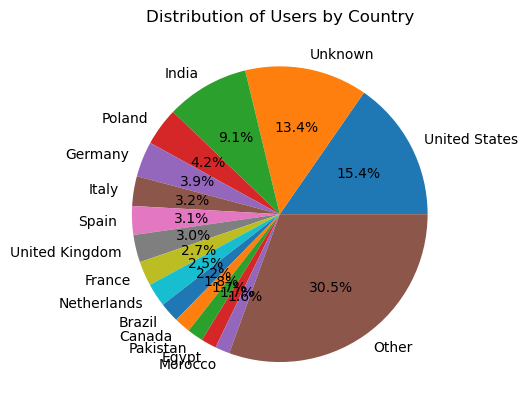

In [ ]:
country_grouped = team_members_df.groupby("country_name").size().sort_values(ascending=False)
treshold = 0.015
big_percentage = country_grouped[country_grouped / country_grouped.sum() >= treshold]
other_percentage = country_grouped[country_grouped / country_grouped.sum() < treshold]
big_percentage["Other"] = other_percentage.sum()
plt.pie(big_percentage, labels=big_percentage.index, autopct='%1.1f%%')
plt.title('Distribution of Users by Country')
plt.show()

In [ ]:
#other countries
other_percentage.index

Index(['Australia', 'Indonesia', 'Ukraine', 'Vietnam', 'Romania', 'Sri Lanka',
       'Argentina', 'China', 'Switzerland', 'Tunisia',
       ...
       'New Caledonia', 'North Korea', 'Mali', 'Malta', 'Monaco',
       'Christmas Island', 'Botswana', 'British Virgin Islands', 'Uzbekistan',
       'Uruguay'],
      dtype='object', name='country_name', length=130)

## Team size

In [96]:
team_size_data = team_members_df.groupby("team_id").size()
team_size_data.describe()

count    112.000000
mean      25.580357
std       79.589107
min        1.000000
25%        5.750000
50%       10.000000
75%       20.250000
max      758.000000
dtype: float64

In [51]:
team_size_data.sort_values()

team_id
3766      1
7280      1
7317      1
394       1
5645      1
       ... 
6789     78
6575     84
6462    126
2102    369
6003    758
Length: 112, dtype: int64

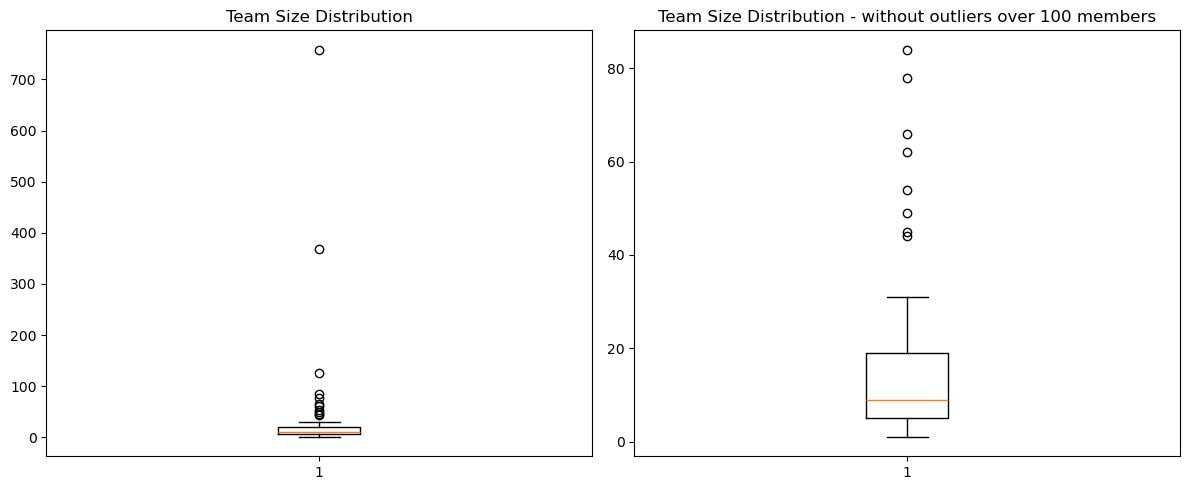

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

upper_bound = 100
filtered = team_size_data[team_size_data <= upper_bound]

axes[0].boxplot(team_size_data)
axes[0].set_title('Team Size Distribution')
axes[1].boxplot(filtered)
axes[1].set_title('Team Size Distribution - without outliers over 100 members')

plt.tight_layout()
plt.show()


## Odnos ranga tima i ranga članova tima

Doduše, ovo je statistika na 100 najboljih timova i njihovih 900-ish neanonimnih članova pa ima smisla da su svi relativno dobri

In [71]:
df1_slim = team_members_df[["id", "name", "rank", "points", "team_id", "role"]]
df2_slim = teams_df[["id", "name", "rank", "points"]]
rank_statistics = df1_slim.merge(df2_slim, left_on="team_id", right_on="id", suffixes=("_user", "_team"))
rank_statistics

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
0,260094,NLTE,247,864,6536,captain,6536,ThugShakers,1,2757
1,1246594,miblak,5,2489,6536,member,6536,ThugShakers,1,2757
2,357237,Sm1l3z,328,710,6536,member,6536,ThugShakers,1,2757
3,143207,22sh,439,550,6536,member,6536,ThugShakers,1,2757
4,1387134,kapiushion03,513,460,6536,member,6536,ThugShakers,1,2757
...,...,...,...,...,...,...,...,...,...,...
2860,523428,GetRektBoy724,unranked,0,5768,member,5768,HCS,100,1062
2861,2782348,erzy,unranked,0,5768,member,5768,HCS,100,1062
2862,1225341,Zumpyx,562,401,6676,captain,6676,CyberFourier,100,1062
2863,1487037,Lusowen,218,942,6676,member,6676,CyberFourier,100,1062


U tablici je 2865 redaka tj. natjecatelja, ali je maksimalni rang 943. To je zato što se rank dijeli među natjecateljima s istim brojem bodova i dodatno postoji 930 natjecatelja s rankom 943. Većina njih ima 0 bodova, ali ne razumijem zašto postoji 176 natejcatelja koji imaju više od 0 bodova, ali su svejedno ranka 943.

In [72]:
rank_statistics[rank_statistics["rank_user"] == 943]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
85,40613,MADE,943,0,1709,member,1709,WinBARs,6,2570
86,55159,raiden99,943,0,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2856,1863416,anarchistxxx,943,0,5768,member,5768,HCS,100,1062
2857,1996861,mintcocs,943,1,5768,member,5768,HCS,100,1062
2858,2163976,honque,943,0,5768,member,5768,HCS,100,1062
2859,2318132,TinyTidy,943,0,5768,member,5768,HCS,100,1062


In [73]:
rank_statistics[(rank_statistics["rank_user"] == 943) & (rank_statistics["points_user"] > 0)]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
88,122838,Imm0,943,580,1709,member,1709,WinBARs,6,2570
89,124247,kosinw,943,4,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2789,833625,SecurityEagle,943,1,4161,member,4161,L3G10N,97,1085
2795,1373600,Cosmoxe,943,3,4161,member,4161,L3G10N,97,1085
2835,111344,Rumo,943,27,5490,member,5490,OPTIMA,99,1064
2836,113741,phate32,943,16,5490,member,5490,OPTIMA,99,1064


In [77]:
rank_statistics.loc[rank_statistics["rank_user"] == 'unranked', "rank_user"] = np.nan

In [78]:
rank_statistics["rank_user"]

0       247
1         5
2       328
3       439
4       513
       ... 
2860    NaN
2861    NaN
2862    562
2863    218
2864    943
Name: rank_user, Length: 2865, dtype: object

Text(0.5, 1.0, 'User Rank vs Team Rank (excluding largest teams and zero points)')

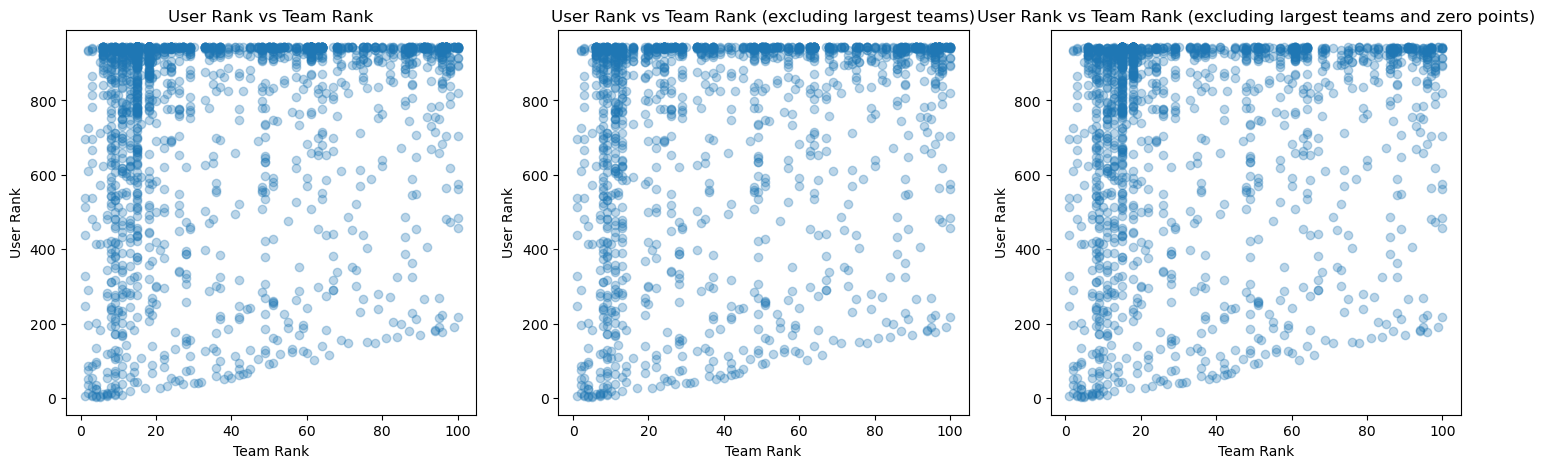

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(rank_statistics["rank_team"], rank_statistics["rank_user"], alpha=0.3)
axes[0].set_xlabel("Team Rank")
axes[0].set_ylabel("User Rank")
axes[0].set_title("User Rank vs Team Rank")

# largest teams:
# 6462    126
# 2102    369
# 6003    758
rank_statistics_no_outliers = rank_statistics[~rank_statistics["id_team"].isin([6003, 2102, 6462])]
axes[1].scatter(rank_statistics_no_outliers["rank_team"], rank_statistics_no_outliers["rank_user"], alpha=0.3)
axes[1].set_xlabel("Team Rank")
axes[1].set_ylabel("User Rank")
axes[1].set_title("User Rank vs Team Rank (excluding largest teams)")

rank_statistics_no_0_points = rank_statistics[rank_statistics["points_user"] > 0]
axes[2].scatter(rank_statistics_no_0_points["rank_team"], rank_statistics_no_0_points["rank_user"], alpha=0.3)
axes[2].set_xlabel("Team Rank")
axes[2].set_ylabel("User Rank")
axes[2].set_title("User Rank vs Team Rank (excluding largest teams and zero points)")

In [79]:
rank_correlation = rank_statistics[["rank_user", "rank_team"]].corr()
rank_correlation

,rank_user,rank_team
rank_user,1.000000,0.067334
rank_team,0.067334,1.000000


In [82]:
rank_correlation_no_outliers = rank_statistics_no_outliers[["rank_user", "rank_team"]].corr()
rank_correlation_no_outliers

,rank_user,rank_team
rank_user,1.000000,0.244592
rank_team,0.244592,1.000000


In [85]:
rank_correlation_no_0_points = rank_statistics_no_outliers[rank_statistics_no_outliers["points_user"] > 0][["rank_user", "rank_team"]].corr()
rank_correlation_no_0_points

,rank_user,rank_team
rank_user,1.000000,0.217279
rank_team,0.217279,1.000000


## Odnos ranga i veličine tima

In [132]:
team_rank = teams_df[["id", "rank"]].rename(columns={"rank": "rank_team", "id": "id_team"})
rank_size_statistics = team_rank.merge(team_size_data.rename("team_size"), left_on="id_team", right_index=True)
rank_size_statistics

,id_team,rank_team,team_size
0,6536,1,7
1,7086,2,11
2,5904,3,17
3,6618,4,3
4,6900,4,8
...,...,...,...
107,4161,97,49
108,6821,98,16
109,5490,99,7
110,5768,100,22


In [133]:
team_size_rank_corr = rank_size_statistics['team_size'].corr(rank_size_statistics['rank_team'])
team_size_rank_corr

-0.19219673172538188

In [134]:
rank_size_statistics_no_outliers = rank_size_statistics[~rank_size_statistics["id_team"].isin([6003, 2102, 6462])]
team_size_rank_corr_no_outliers = rank_size_statistics_no_outliers['team_size'].corr(rank_size_statistics_no_outliers['rank_team'])
team_size_rank_corr_no_outliers

-0.25402162336360345

Text(0.5, 1.0, 'Team Size vs Team Rank')

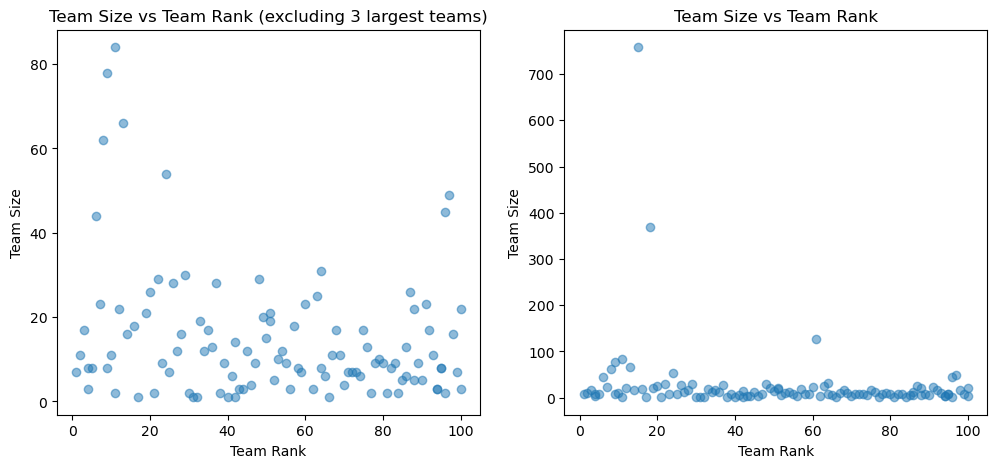

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(rank_size_statistics_no_outliers['rank_team'], rank_size_statistics_no_outliers['team_size'], alpha=0.5)
axes[0].set_xlabel("Team Rank")
axes[0].set_ylabel("Team Size")
axes[0].set_title("Team Size vs Team Rank (excluding 3 largest teams)")

axes[1].scatter(rank_size_statistics["rank_team"], rank_size_statistics['team_size'], alpha=0.5)
axes[1].set_xlabel("Team Rank")
axes[1].set_ylabel("Team Size")
axes[1].set_title("Team Size vs Team Rank")

In [137]:
# Ima li statističke korelacije između veličine tima i ranga tima?
from scipy.stats import spearmanr, pearsonr

rho, p_s = spearmanr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
r, p_p = pearsonr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)

Spearman: -0.18959730214727222 0.04526337139728963
Pearson: -0.19219673172538176 0.04233934558156263


In [138]:
avg = rank_size_statistics.groupby('team_size')['rank_team'].agg(['mean','count','std']).reset_index()
avg

,team_size,mean,count,std
0,1,38.000000,6,16.309506
1,2,54.750000,8,33.139316
2,3,62.125000,8,32.900011
3,4,58.000000,2,16.970563
4,5,78.750000,4,17.951323
5,6,66.500000,4,19.052559
6,7,57.142857,7,33.178450
7,8,51.500000,8,39.889132
8,9,61.750000,8,24.123196
9,10,66.000000,2,18.384776


Text(0.5, 1.0, 'Average Team Rank vs Team Size with Standard Deviation')

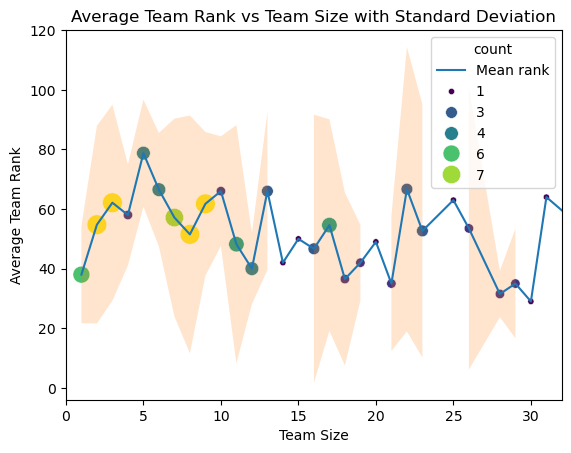

In [141]:
plt.plot(avg['team_size'], avg['mean'], color='C0', label='Mean rank')
sns.scatterplot(
    data=avg,
    x='team_size',
    y='mean',
    size='count',        # map point size to count
    sizes=(20, 200),     # min and max dot size
    hue='count',         # optional: color by count too
    palette='viridis'
)
plt.xlim(0, 32)
plt.fill_between(avg['team_size'], avg['mean'] - avg['std'], avg['mean'] + avg['std'], alpha=0.2, label='±1 SE')
plt.xlabel('Team Size')
plt.ylabel('Average Team Rank')
plt.title('Average Team Rank vs Team Size with Standard Deviation')

## Odnos korisničkih bodova i timskih bodova

In [142]:
team_points = teams_df[["id", "points"]].rename(columns={"points": "points_team", "id": "id_team"})
member_points = team_members_df[["id", "team_id", "points"]].rename(columns={"points": "points_user", "team_id": "id_team", "id": "id_user"})
team_vs_member_points = member_points.merge(team_points, on="id_team")
team_vs_member_points

,id_user,id_team,points_user,points_team
0,260094,6536,864,2757
1,1246594,6536,2489,2757
2,357237,6536,710,2757
3,143207,6536,550,2757
4,1387134,6536,460,2757
...,...,...,...,...
2860,523428,5768,0,1062
2861,2782348,5768,0,1062
2862,1225341,6676,401,1062
2863,1487037,6676,942,1062


<Axes: title={'center': 'User Points vs Team Points'}, xlabel='points_team', ylabel='points_user'>

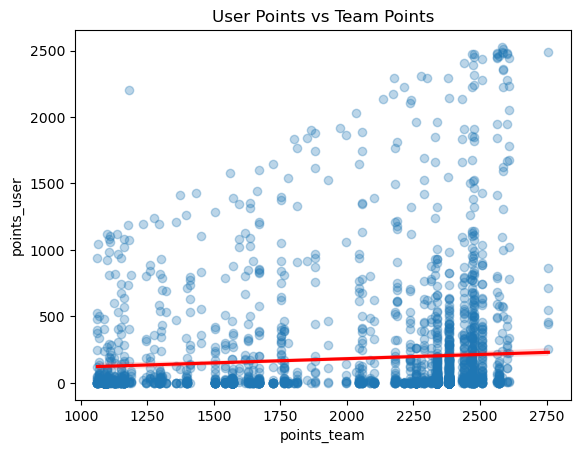

In [153]:
plt.scatter(team_vs_member_points['points_team'], team_vs_member_points['points_user'], alpha=0.3)
plt.xlabel("Team Points")
plt.ylabel("User Points")
plt.title("User Points vs Team Points")
sns.regplot(x='points_team', y='points_user', data=team_vs_member_points, scatter=False, color='red')

In [154]:
corr_points = team_vs_member_points[['points_team', 'points_user']].corr()
corr_points

,points_team,points_user
points_team,1.000000,0.071964
points_user,0.071964,1.000000


## Što natjecatelji najviše rješavaju

In [31]:
users_categories_df.describe()

,owned_flags,total_flags,completion_percentage,avg_user_solved
count,5688.000000,15072.000000,15072.000000,15072.000000
mean,6.585267,50.062500,5.929804,13.678750
std,9.996066,50.779963,14.369476,13.033243
min,1.000000,4.000000,0.000000,2.080000
25%,1.000000,12.500000,0.000000,3.720000
50%,3.000000,19.500000,0.000000,11.380000
75%,8.000000,81.250000,5.000000,16.542500
max,145.000000,161.000000,100.000000,50.770000


Volumno, najviše igraju web pa ostale standardne kategorije pa onda ostale kategorije na HTB. MEđutim, kad se gleda postotak riješenosti dostupnih zadataka, najveća je prosječna riješenost OSINT zadataka

<BarContainer object of 16 artists>

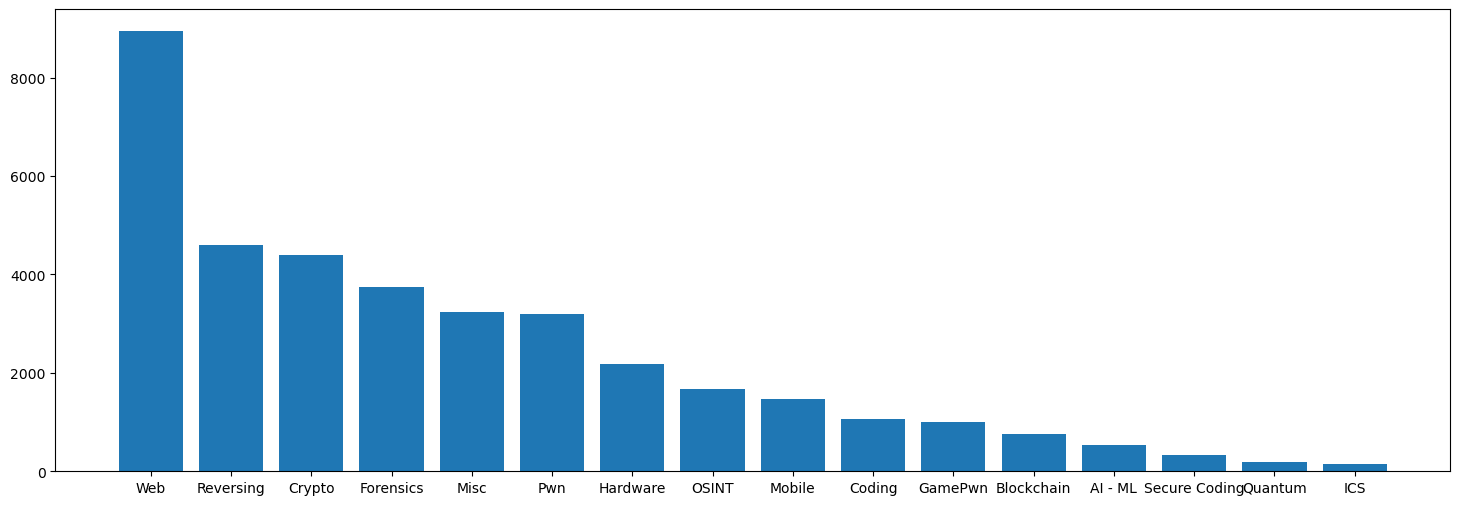

In [11]:
owned_per_category = users_categories_df.groupby("category")["owned_flags"].sum().sort_values(ascending=False)
plt.figure(figsize=(18,6))
plt.bar(owned_per_category.index, owned_per_category.values)

<BarContainer object of 16 artists>

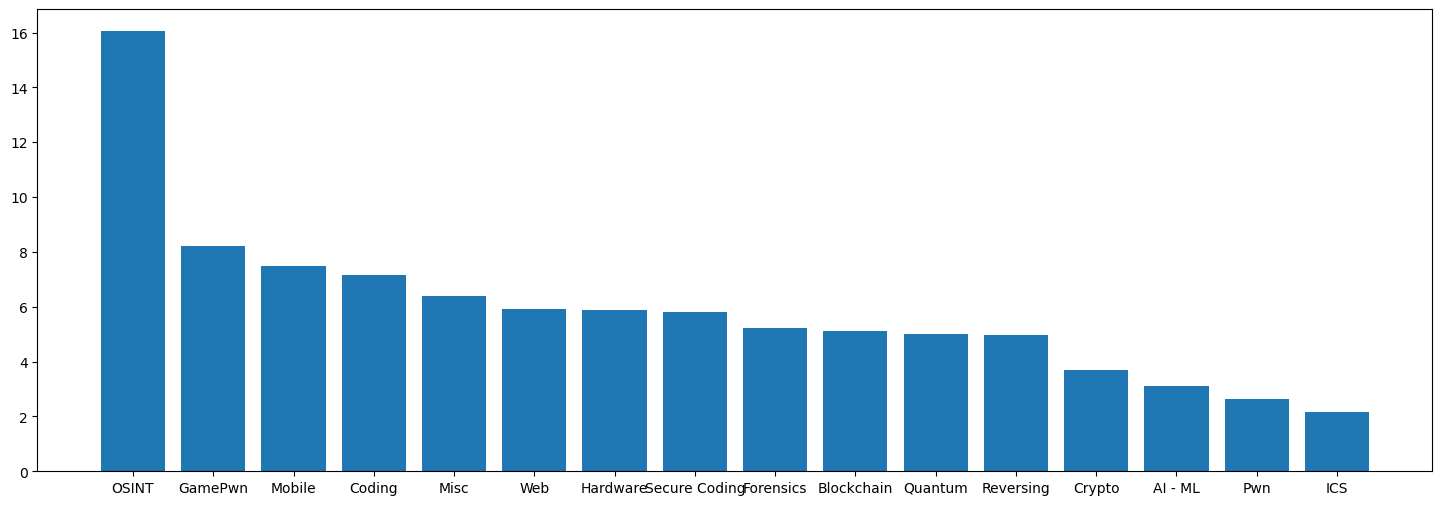

In [13]:
owned_per_category_percentage = users_categories_df.groupby("category")["completion_percentage"].mean().sort_values(ascending=False)
plt.figure(figsize=(18,6))
plt.bar(owned_per_category_percentage.index, owned_per_category_percentage.values)  

<Axes: xlabel='category', ylabel='owned_flags'>

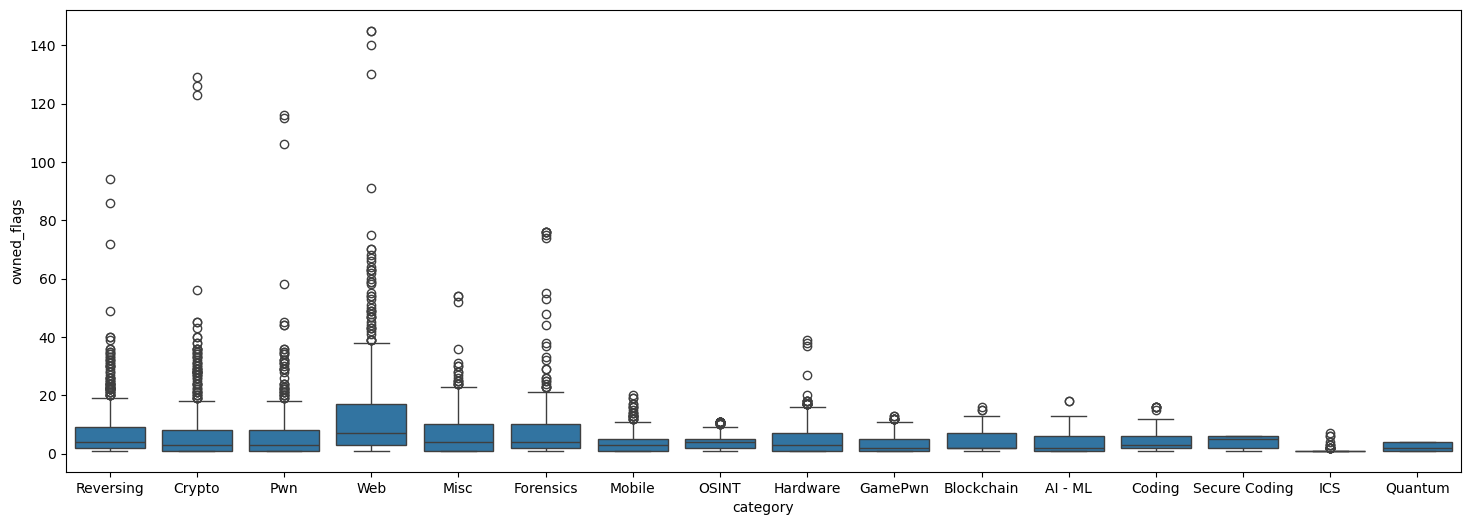

In [35]:
user_categories_box = (users_categories_df.groupby(['id', 'category']).size().reset_index(name='solved_count'))
plt.figure(figsize=(18, 6))
sns.boxplot(data=users_categories_df, x="category", y="owned_flags")

## Profili igrača

In [3]:
# matrica user-category sa postocima riješenosti zadataka u kategoriji
user_category_completion = users_categories_df.pivot_table(
    index='id',
    columns='category',
    values='completion_percentage',  # or owned_flags / total_flags
    fill_value=0
)

In [4]:
main_categories = ['Web', 'Pwn', 'Crypto', 'Forensics', 'Reversing', 'Misc', 'OSINT']
user_category_completion_main_categories = users_categories_df[users_categories_df['category'].isin(main_categories)].pivot_table(
    index='id',
    columns='category',
    values='completion_percentage',  # or owned_flags / total_flags
    fill_value=0
)
# nije normalizirano po retku da bih imala stvarnu predodzbu koliki postotak dostupnih zadataka su rijesili 
# ako je netko sve radio malo i to malo se zbroji u 1, onda ce izgledati kao da je jako dobar u tim kategorijama, ali nije jer je rjesavao samo malo

### Heatmap riješenosti zadataka po kategoriji za svakog usera

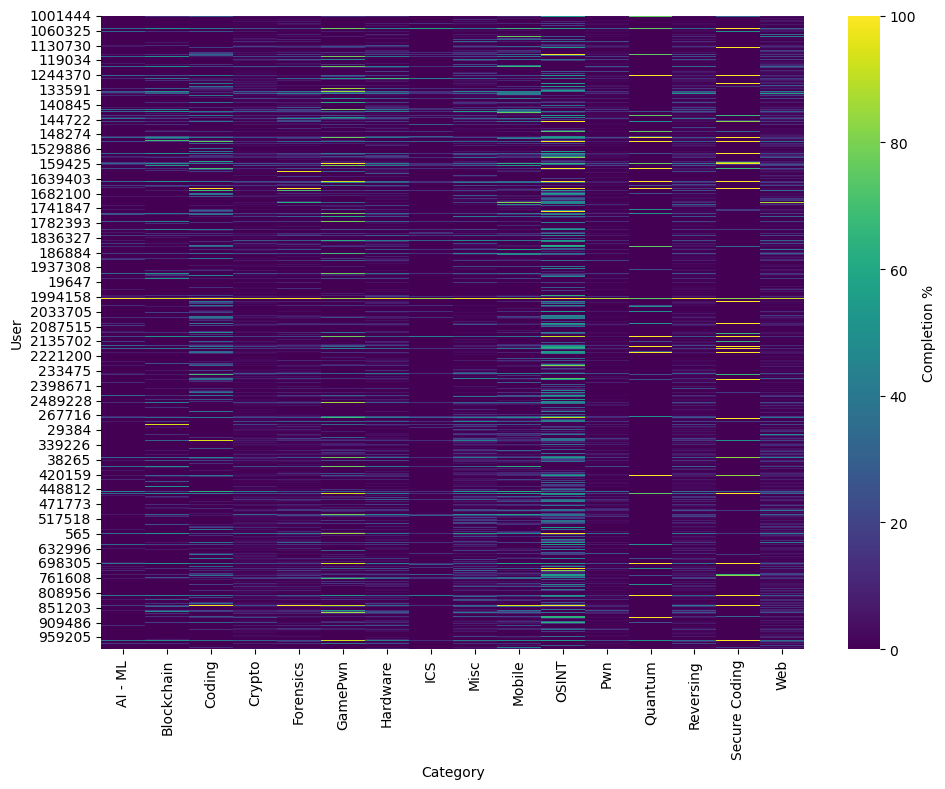

In [75]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    user_category_completion,
    cmap='viridis',
    cbar_kws={'label': 'Completion %'},
)
plt.xlabel('Category')
plt.ylabel('User')
plt.tight_layout()
plt.show()

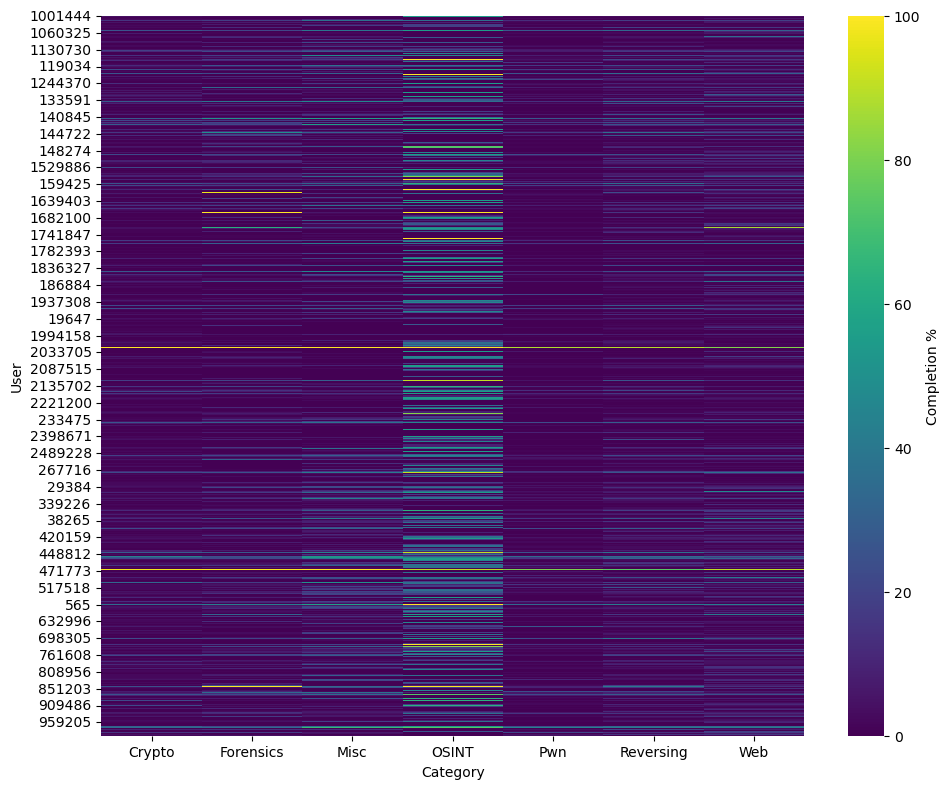

In [76]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    user_category_completion_main_categories,
    cmap='viridis',
    cbar_kws={'label': 'Completion %'},
)
plt.xlabel('Category')
plt.ylabel('User')
plt.tight_layout()
plt.show()

### Clustering po specijalnosti/profilima - originalne grupe

/tmp/ipykernel_688533/1372796516.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles_main = profiles_main.fillna(0)


Text(0, 0.5, 'Inertia')

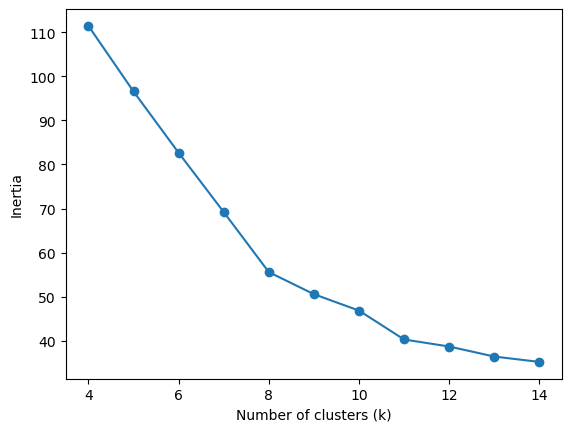

In [5]:
row_sums_main = user_category_completion_main_categories.sum(axis=1)

profiles_main = user_category_completion_main_categories.div(row_sums_main.replace(0, pd.NA), axis=0)
profiles_main = profiles_main.fillna(0)

inertias = []
for k in range(4, 15):
    km = KMeans(n_clusters=k, random_state=0)
    clusters = km.fit_predict(profiles_main)
    inertias.append(km.inertia_)
    
plt.plot(range(4, 15), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

Text(0, 0.5, 'Silhouette Score')

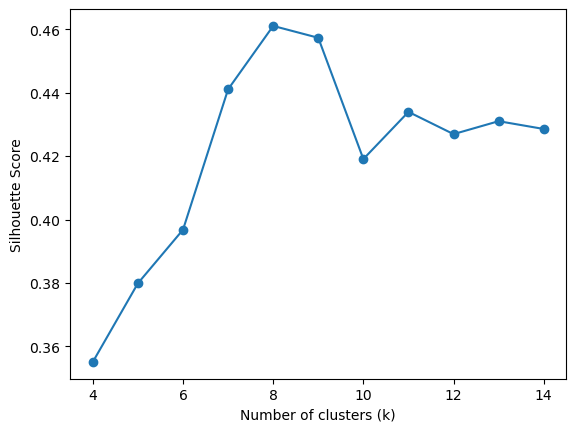

In [6]:
sil_scores = []
for k in range(4, 15):
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = km.fit_predict(profiles_main)
    sil_scores.append(silhouette_score(profiles_main, labels))
plt.plot(range(4, 15), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

#### Clustering na cijelom datasetu na temelju glavnih kategorija - 8 clustera

Iz grafova analize siluete (al ovo nije analiza siluete nego samo siluette score), i metode koljena odlučujemo da je optimalni broj grupa 8.

In [ ]:
k = 8  # number of archetypes you want
km = KMeans(n_clusters=k, random_state=0, n_init='auto')

In [10]:
cluster_info = {
    0: {"name": "Reversing specialist", "color": "blue"},
    1: {"name": "OSINT Generalist", "color": "orange"},
    2: {"name": "Well-rounded generalist", "color": "green"},
    3: {"name": "Web specialist", "color": "red"},
    4: {"name": "Crypto specialist", "color": "purple"},
    5: {"name": "Misc specialist", "color": "brown"},
    6: {"name": "Noob", "color": "pink"},
    7: {"name": "OSINT specialist", "color": "gray"}
}

# Helper objects for plotting
name_map = {k: v["name"] for k, v in cluster_info.items()}
color_map = {v["name"]: v["color"] for k, v in cluster_info.items()}
ordered_names = [cluster_info[i]["name"] for i in range(8)]

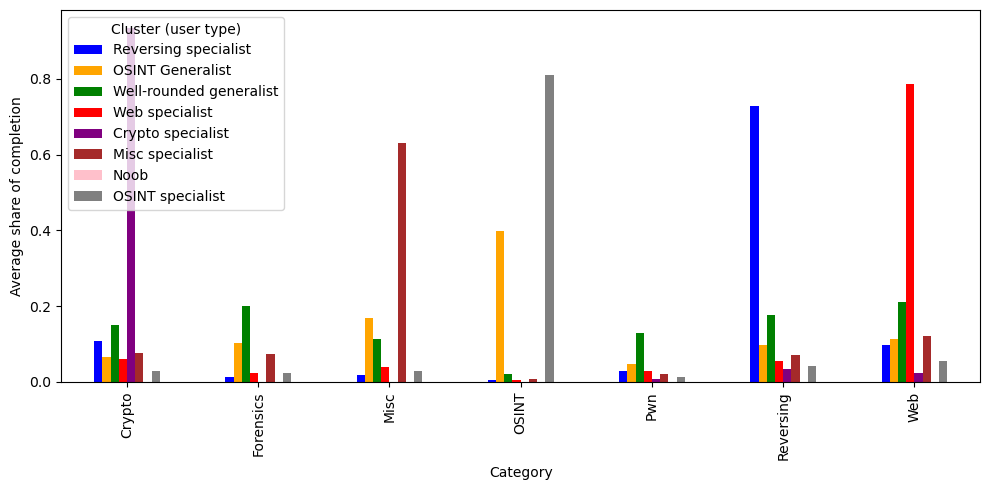

In [ ]:
clusters = km.fit_predict(profiles_main)
profile_clustered_main = profiles_main.copy()
profile_clustered_main['cluster'] = clusters

cluster_mean_main = profile_clustered_main.groupby('cluster').mean()
plot_data = cluster_mean_main.T

plot_data.columns = [name_map[i] for i in plot_data.columns]
ax = plot_data.plot(kind='bar', figsize=(10, 5), color=[color_map[name] for name in plot_data.columns])
plt.xlabel('Category')
plt.ylabel('Average share of completion')
plt.legend(title='Cluster (user type)', labels=ordered_names)
plt.tight_layout()
plt.show()


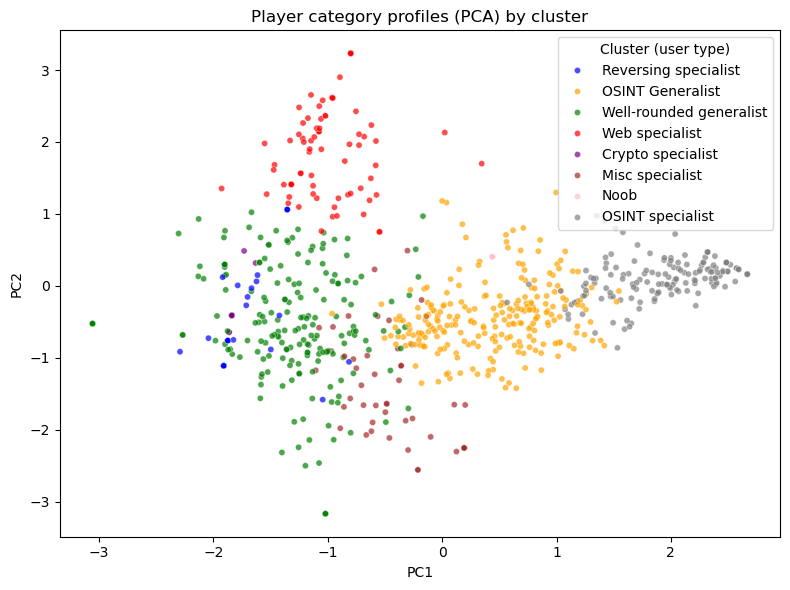

In [10]:
# ok al koje su ovo komponente?
scaler = StandardScaler()
X_scaled = scaler.fit_transform(profiles_main)

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, index=profiles_main.index, columns=['pc1', 'pc2'])
plot_df['cluster_name'] = pd.Series(clusters, index=profiles_main.index).map(name_map)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='pc1',
    y='pc2',
    hue='cluster_name',
    hue_order=ordered_names,
    palette=color_map,
    s=20,
    alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Player category profiles (PCA) by cluster')
plt.legend(title='Cluster (user type)')
plt.tight_layout()
plt.show()


In [ ]:
centroids = pd.DataFrame(km.cluster_centers_,
                         columns=profiles_main.columns)

In [81]:
centroids*100
# kategorija 6 je čudna

category,Crypto,Forensics,Misc,OSINT,Pwn,Reversing,Web
0,1.089141e+01,1.263889e+00,1.852545e+00,5.000000e-01,2.903980e+00,7.290786e+01,9.680315e+00
1,6.674395e+00,1.036279e+01,1.690198e+01,3.988382e+01,4.867511e+00,9.855049e+00,1.145447e+01
2,1.491703e+01,2.010686e+01,1.123813e+01,2.226127e+00,1.281322e+01,1.768487e+01,2.101376e+01
3,6.114811e+00,2.283753e+00,3.983966e+00,5.160727e-01,2.882913e+00,5.555334e+00,7.866315e+01
4,9.346491e+01,1.387779e-15,0.000000e+00,0.000000e+00,6.578947e-01,3.508772e+00,2.368421e+00
5,7.529246e+00,7.306533e+00,6.291759e+01,6.722689e-01,2.162064e+00,7.212774e+00,1.219952e+01
6,-4.163336e-15,-8.326673e-15,-1.387779e-15,-1.387779e-14,-2.081668e-15,-2.775558e-15,5.551115e-15
7,2.871925e+00,2.409657e+00,3.025946e+00,8.091134e+01,1.189987e+00,4.176529e+00,5.414615e+00


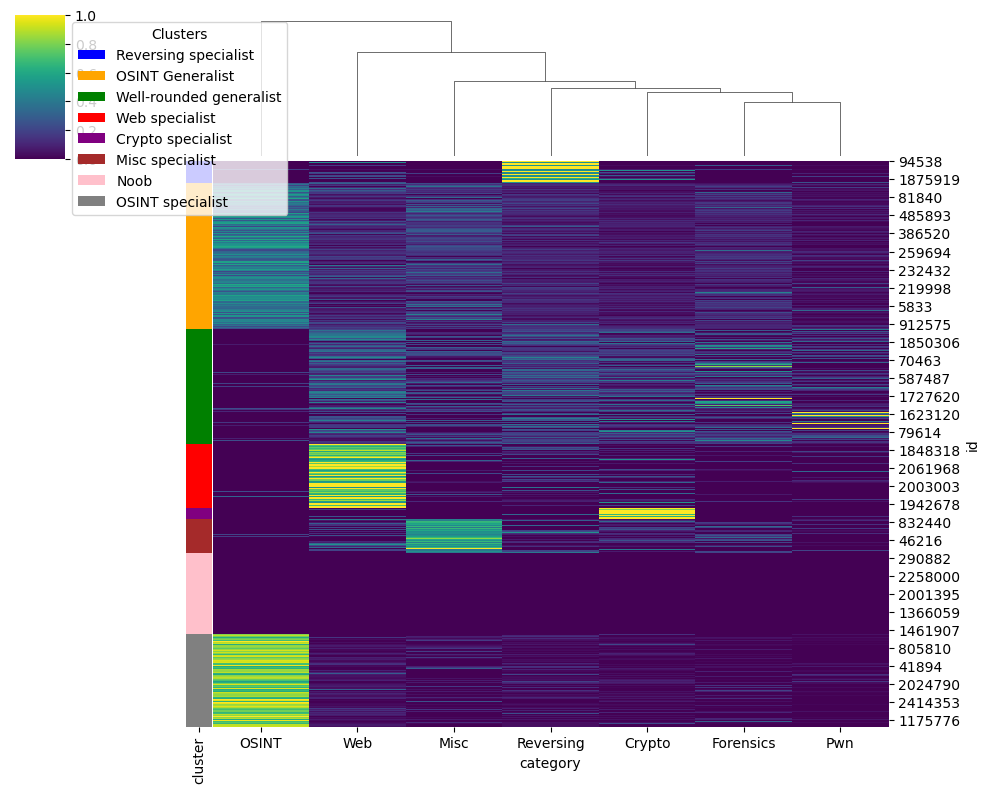

In [ ]:
profile_sorted = profile_clustered_main.sort_values('cluster')
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info[x]['color'])
heatmap_data = profile_sorted.drop(columns=['cluster']) # mičem cluster column da se ne plota u heatmap

sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # This adds the cluster color column
    row_cluster=False,      # Important: Keep rows in our sorted cluster order
    col_cluster=True,       # Let Seaborn group similar categories (e.g., Web near Crypto)
    cmap='viridis',         # Color scale for the "share of completion"
    figsize=(10, 8),
    standard_scale=1    # Normalizes 0-1 so categories are comparable
)

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info.values()
]

plt.legend(
    handles=legend_elements, 
    title='Clusters', 
    bbox_to_anchor=(1, 1), 
    loc='upper left'
)
plt.show()

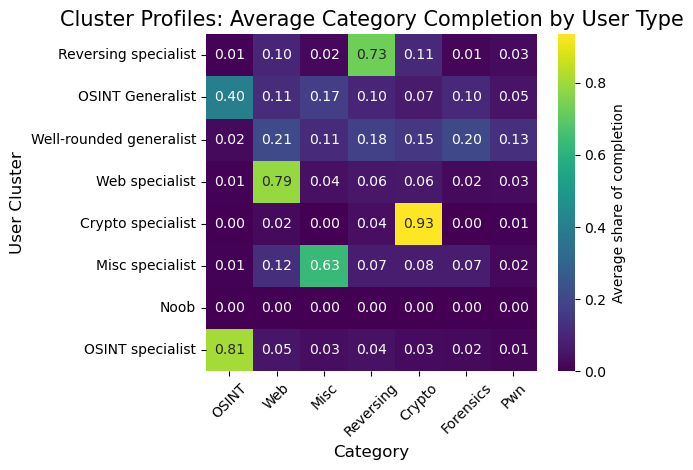

In [23]:
# Average archetype profiles
category_order = ["OSINT", "Web", "Misc", "Reversing", "Crypto", "Forensics", "Pwn"]
avg_heatmap_data = cluster_mean_main.copy()
avg_heatmap_data.index = avg_heatmap_data.index.map(lambda x: cluster_info[x]['name'])
avg_heatmap_data = avg_heatmap_data.reindex(columns=category_order)
sns.heatmap(
    avg_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar_kws={'label': 'Average share of completion'} 
)

plt.title('Cluster Profiles: Average Category Completion by User Type', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('User Cluster', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8196/3948537619.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles = profiles.fillna(0)


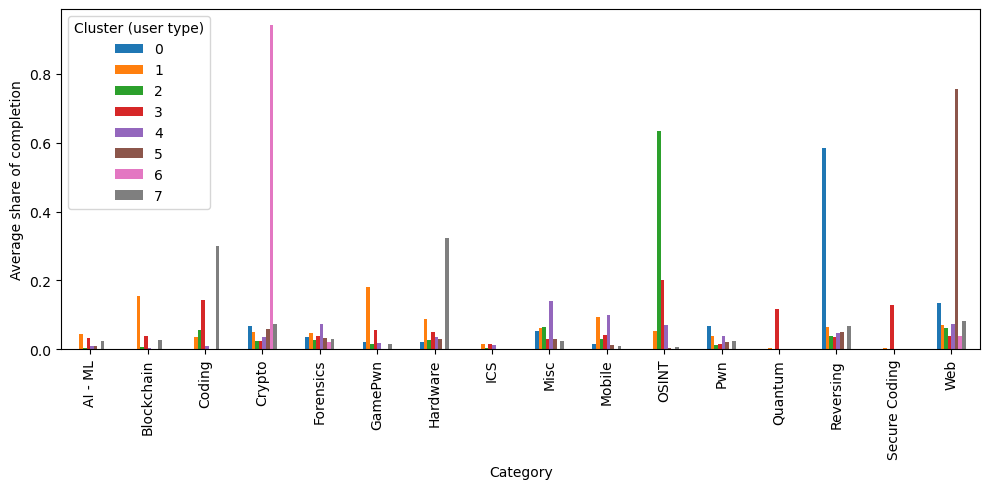

In [ ]:
# mislim da ovo nisam smjela napraviti - novo grupiranje na "novom" datasetu - trebala sam samo prepisati clustering iz main dataseta
# row_sums = user_category_completion.sum(axis=1)

# profiles = user_category_completion.div(row_sums.replace(0, pd.NA), axis=0)
# profiles = profiles.fillna(0)

# clusters = km.fit_predict(profiles)

# profile_clustered = profiles.copy()
# profile_clustered['cluster'] = clusters
# cluster_mean = profile_clustered.groupby('cluster').mean()

# cluster_mean.T.plot(kind='bar', figsize=(10, 5))
# plt.xlabel('Category')
# plt.ylabel('Average share of completion')
# plt.legend(title='Cluster (user type)')
# plt.tight_layout()
# plt.show()

### Redefiniranje dataseta - grupiranje čudnih kategorija u najsličniju glavnu

In [29]:
group_map = {
    'Web': 'Web',
    'Pwn': 'Pwn',
    'GamePwn': 'Pwn',
    'Reversing': 'Reversing',
    'Crypto': 'Crypto',
    'Quantum': 'Crypto',
    'Forensics': 'Forensics',
    'Coding': 'Misc',
    'OSINT': 'Misc',
    'Misc': 'Misc',
    'Secure Coding': 'Misc',
    'Hardware': 'Hardware',
    'ICS': 'ICS',
    'Mobile': 'Mobile',
    'AI - ML': 'AI - ML',
    'Blockchain': 'Blockchain'}

#### Clustering po specijalnosti/profilima - nove grupe, treniranje na svim grupama = Krivo

/tmp/ipykernel_116385/2504969530.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles = profiles.fillna(0)


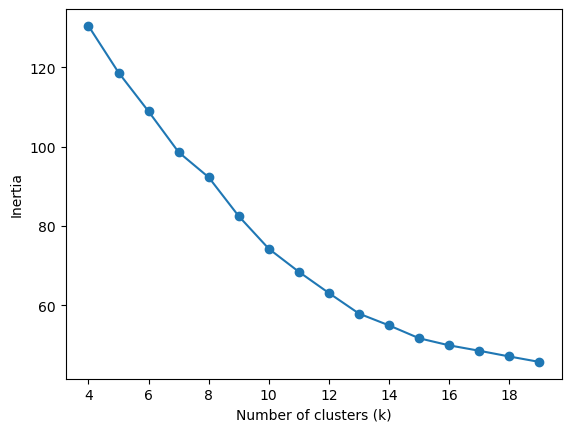

In [ ]:
# Ne sviđa mi se kako ovo izgleda, ispod isprobala treniranje na glavnim kategorijama umjesto na svim

# users_categories_grouped_df = users_categories_df.copy()
# users_categories_grouped_df['category'] = users_categories_grouped_df['category'].map(group_map)

# meta = users_categories_grouped_df.groupby(['id', 'category']).agg(owned_flags_sum=('owned_flags', 'sum'), 
#                                                                         total_flags_sum=('total_flags', 'sum')).reset_index()

# meta['completion_percent'] = (
#     meta['owned_flags_sum'] / meta['total_flags_sum'] * 100
# )

# user_meta = meta.pivot_table(
#     index='id',
#     columns='category',
#     values='completion_percent',
#     fill_value=0
# )

# row_sums = user_meta.sum(axis=1)
# profiles = user_meta.div(row_sums.replace(0, pd.NA), axis=0)
# profiles = profiles.fillna(0)

# inertias = []
# for k in range(4, 20):
#     km = KMeans(n_clusters=k, random_state=0)
#     clusters = km.fit_predict(profiles)
#     inertias.append(km.inertia_)
    
# plt.plot(range(4, 20), inertias, marker='o')
# plt.xlabel('Number of clusters (k)')
# plt.ylabel('Inertia')
# plt.show()

Text(0, 0.5, 'Silhouette Score')

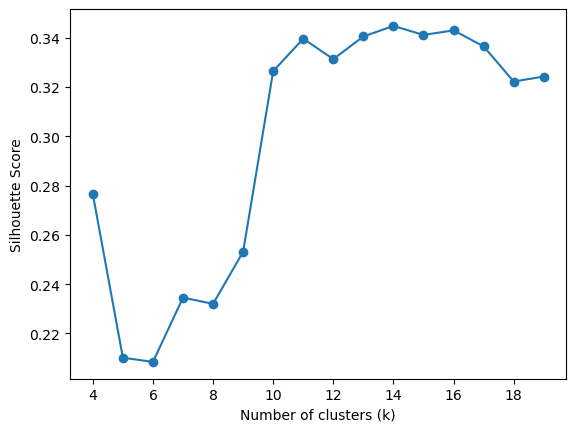

In [ ]:
# sil_scores = []
# for k in range(4, 20):
#     km = KMeans(n_clusters=k, random_state=0, n_init='auto')
#     labels = km.fit_predict(profiles)
#     sil_scores.append(silhouette_score(profiles, labels))
# plt.plot(range(4, 20), sil_scores, marker='o')
# plt.xlabel('Number of clusters (k)')
# plt.ylabel('Silhouette Score')

#### Clustering po specijalnosti/profilima - nove grupe, treniranje na glavnim grupama

/tmp/ipykernel_697858/1722121395.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles = profiles.fillna(0)


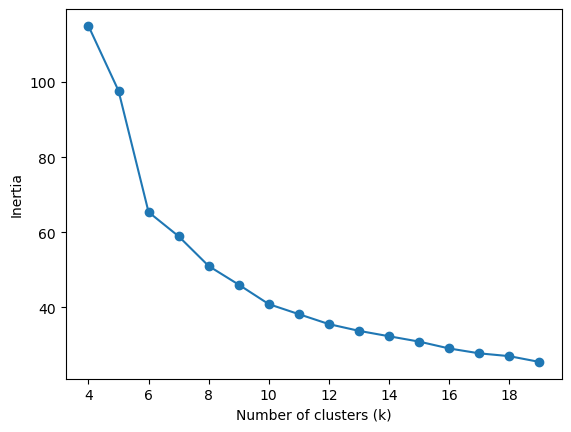

In [30]:
# treniranje samo na glavim kategorijama

users_categories_grouped_df = users_categories_df.copy()
users_categories_grouped_df['category'] = users_categories_grouped_df['category'].map(group_map)


meta = users_categories_grouped_df[users_categories_grouped_df['category'].isin(['Web', 'Pwn', 'Crypto', 'Forensics', 'Reversing', 'Misc'])].groupby(['id', 'category']).agg(owned_flags_sum=('owned_flags', 'sum'), 
                                                                        total_flags_sum=('total_flags', 'sum')).reset_index()

meta['completion_percent'] = (
    meta['owned_flags_sum'] / meta['total_flags_sum'] * 100
)

user_meta = meta.pivot_table(
    index='id',
    columns='category',
    values='completion_percent',
    fill_value=0
)

row_sums = user_meta.sum(axis=1)
profiles = user_meta.div(row_sums.replace(0, pd.NA), axis=0)
profiles = profiles.fillna(0)

inertias = []
for k in range(4, 20):
    km = KMeans(n_clusters=k, random_state=0)
    clusters = km.fit_predict(profiles)
    inertias.append(km.inertia_)
    
plt.plot(range(4, 20), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

#### Clustering na grupiranom datasetu na temelju glavnih kategorija - 6 clustera

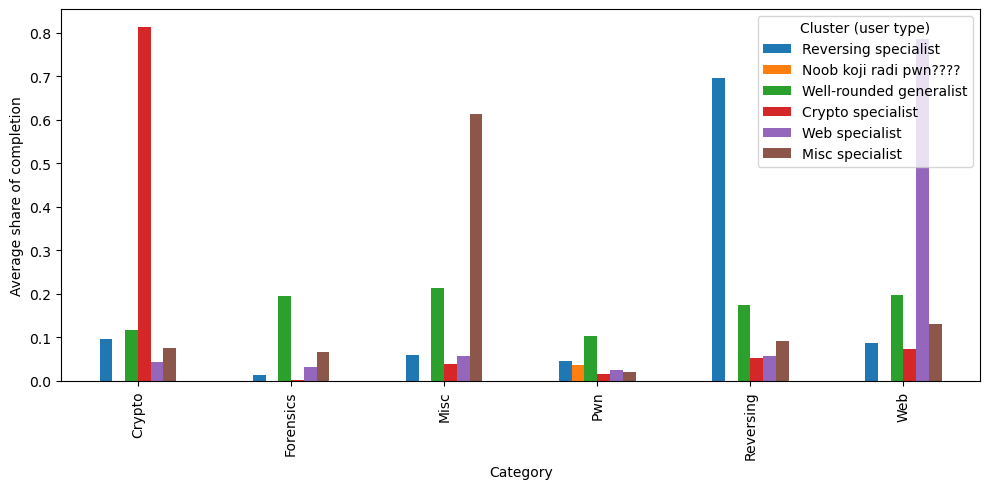

In [36]:
# Iako je supposedly optimalan, meni ovaj clustering nema smisla jer su ljudi koji su riješili puno pwn clusterani s ljuidima koji ne znaju apsolutno ništa. 

km = KMeans(n_clusters=6, random_state=0, n_init='auto')
clusters = km.fit_predict(profiles)
profile_clustered_main = profiles.copy()
profile_clustered_main['cluster'] = clusters

cluster_mean = profile_clustered_main.groupby('cluster').mean()
cluster_mean.T.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Category')
plt.ylabel('Average share of completion')
plt.legend(title='Cluster (user type)', labels=['Reversing specialist', 'Noob koji radi pwn????', 'Well-rounded generalist', 'Crypto specialist', 'Web specialist', 'Misc specialist'])
plt.tight_layout()
plt.show()

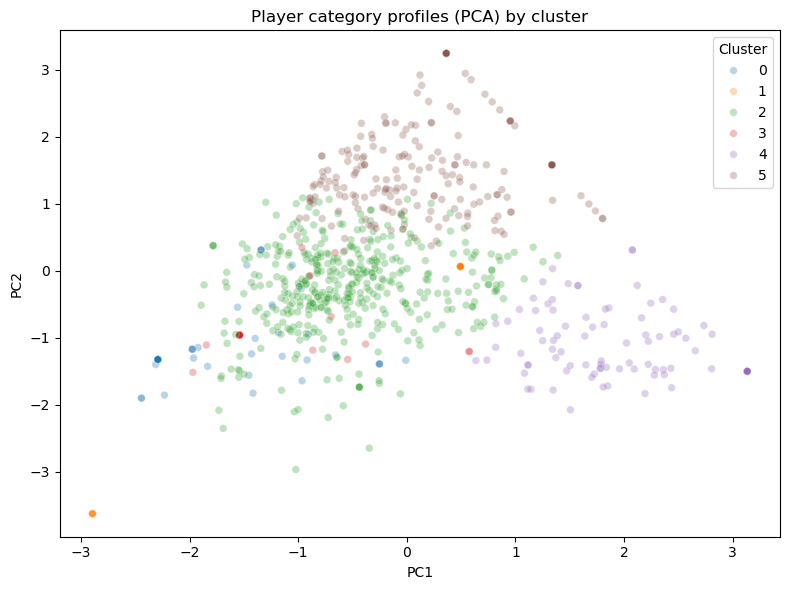

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(profiles)

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, index=profiles.index,
                       columns=['pc1', 'pc2'])
plot_df['cluster'] = clusters

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='tab10',
    s=30,
    alpha=0.3
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Player category profiles (PCA) by cluster')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [38]:
cluster_info = {
    0: {"name": "Reversing specialist", "color": "blue"},
    1: {"name": "Noob koji radi pwn????", "color": "orange"},
    2: {"name": "Well-rounded generalist", "color": "green"},
    3: {"name": "Crypto specialist", "color": "red"},
    4: {"name": "Web specialist", "color": "purple"},
    5: {"name": "Misc specialist", "color": "brown"},
}

# Helper objects for plotting
name_map = {k: v["name"] for k, v in cluster_info.items()}
color_map = {v["name"]: v["color"] for k, v in cluster_info.items()}
ordered_names = [cluster_info[i]["name"] for i in range(6)]

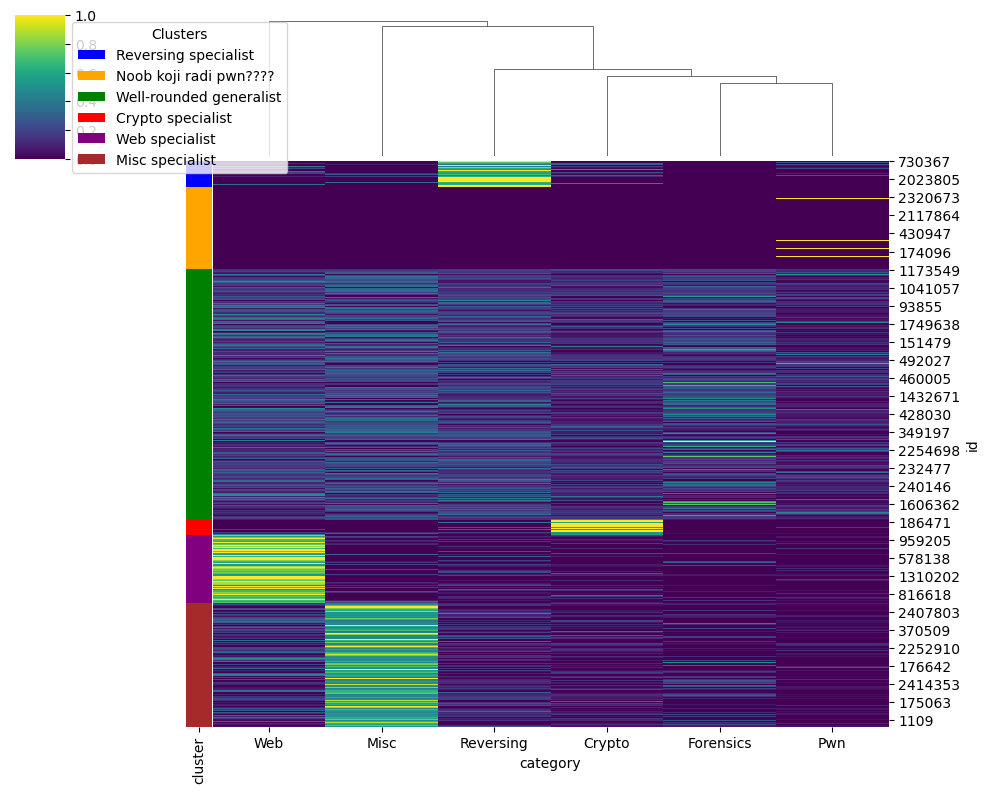

In [39]:
profile_sorted = profile_clustered_main.sort_values('cluster')

# 2. Prepare the color sidebar
# Create a list of colors corresponding to the cluster of each row in our sorted dataframe
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info[x]['color'])

# 3. Separate the features (the categories) for the heatmap
# We drop the 'cluster' column so it doesn't get plotted as data
heatmap_data = profile_sorted.drop(columns=['cluster'])

# 4. Create the Clustermap
sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # This adds the cluster color column
    row_cluster=False,      # Important: Keep rows in our sorted cluster order
    col_cluster=True,       # Let Seaborn group similar categories (e.g., Web near Crypto)
    cmap='viridis',         # Color scale for the "share of completion"
    figsize=(10, 8),
    standard_scale=1    # Normalizes 0-1 so categories are comparable
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info.values()
]

plt.legend(
    handles=legend_elements, 
    title='Clusters', 
    bbox_to_anchor=(1, 1), 
    loc='upper left'
)
plt.show()

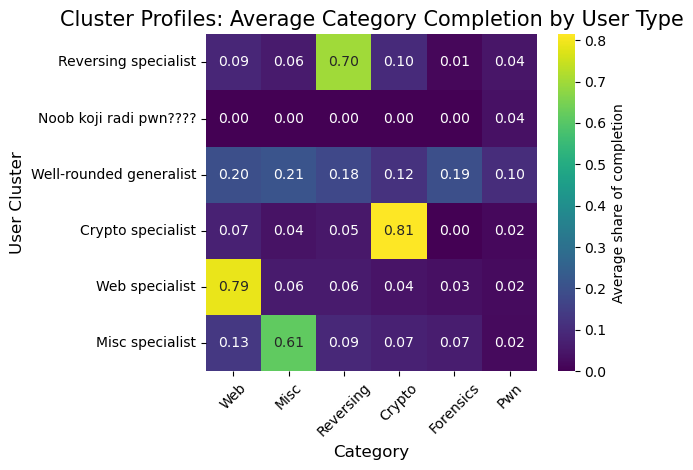

In [40]:
# Average archetype profiles
category_order = ["Web", "Misc", "Reversing", "Crypto", "Forensics", "Pwn"]

avg_heatmap_data = cluster_mean.copy()
avg_heatmap_data.index = avg_heatmap_data.index.map(lambda x: cluster_info[x]['name'])
avg_heatmap_data = avg_heatmap_data.reindex(columns=category_order)
sns.heatmap(
    avg_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar_kws={'label': 'Average share of completion'} 
)

plt.title('Cluster Profiles: Average Category Completion by User Type', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('User Cluster', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Clustering na grupiranom datasetu na temelju glavnih kategorija - 10 clustera

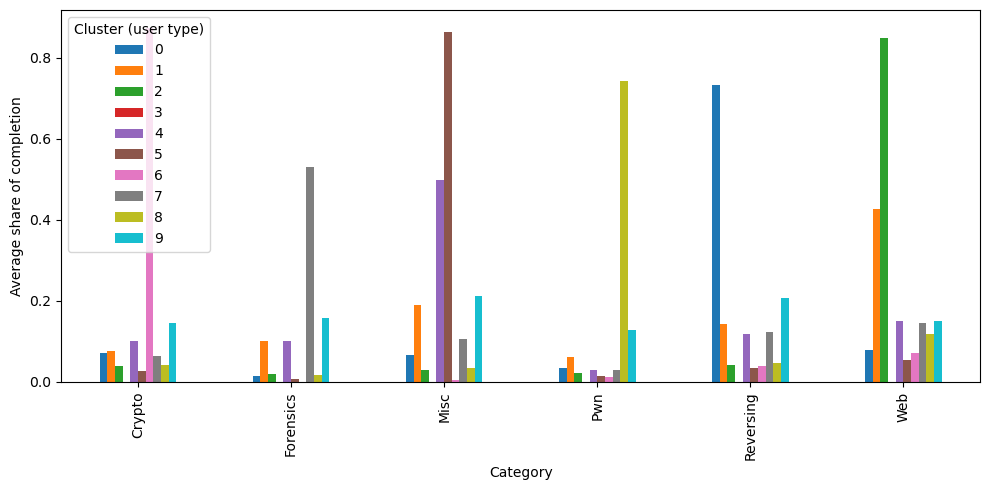

In [41]:
km = KMeans(n_clusters=10, random_state=0, n_init='auto')
clusters = km.fit_predict(profiles)
profile_clustered_main = profiles.copy()
profile_clustered_main['cluster'] = clusters

cluster_mean = profile_clustered_main.groupby('cluster').mean()
cluster_mean.T.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Category')
plt.ylabel('Average share of completion')
plt.legend(title='Cluster (user type)') #, labels=['Reversing specialist', 'Web-heavy generalist', 'Web specialist','Noob', 'Misc-heavy generalist', 'Misc specialist', 'Crypto specialist', 'Forensics Specialist', 'Pwn Specialist', 'Well-rounded generalist'])
plt.tight_layout()
plt.show()

In [42]:
cluster_info = {
    0: {"name": "Reversing specialist", "color": "blue"},
    1: {"name": "Web focused generalist", "color": "orange"},
    2: {"name": "Web specialist", "color": "green"},
    3: {"name": "Noob", "color": "red"},
    4: {"name": "Misc focused generalist", "color": "purple"},
    5: {"name": "Misc specialist", "color": "brown"},
    6: {"name": "Crypto Specialist", "color": "pink"},
    7: {"name": "Forensics specialist", "color": "gray"}, 
    8: {"name": "Pwn Specialist", "color": "tab:olive"},
    9: {"name": "Well rounded Generalist", "color": "cyan"}
}

# Helper objects for plotting
name_map = {k: v["name"] for k, v in cluster_info.items()}
color_map = {v["name"]: v["color"] for k, v in cluster_info.items()}
ordered_names = [cluster_info[i]["name"] for i in range(8)]

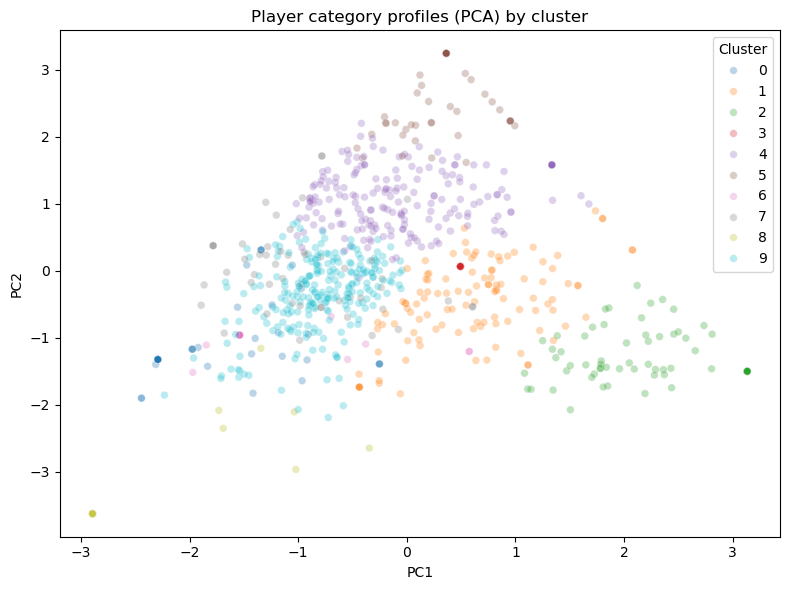

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(profiles)

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, index=profiles.index,
                       columns=['pc1', 'pc2'])
plot_df['cluster'] = clusters

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='tab10',
    s=30,
    alpha=0.3
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Player category profiles (PCA) by cluster')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

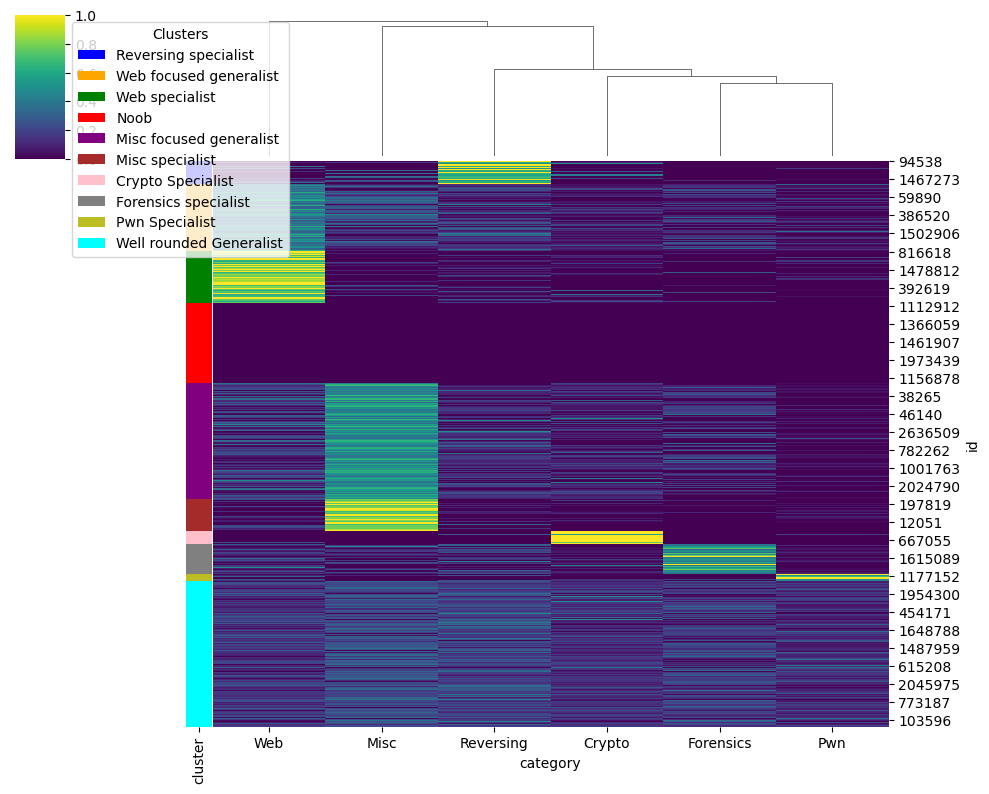

In [44]:
profile_sorted = profile_clustered_main.sort_values('cluster')

# 2. Prepare the color sidebar
# Create a list of colors corresponding to the cluster of each row in our sorted dataframe
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info[x]['color'])

# 3. Separate the features (the categories) for the heatmap
# We drop the 'cluster' column so it doesn't get plotted as data
heatmap_data = profile_sorted.drop(columns=['cluster'])

# 4. Create the Clustermap
sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # This adds the cluster color column
    row_cluster=False,      # Important: Keep rows in our sorted cluster order
    col_cluster=True,       # Let Seaborn group similar categories (e.g., Web near Crypto)
    cmap='viridis',         # Color scale for the "share of completion"
    figsize=(10, 8),
    standard_scale=1    # Normalizes 0-1 so categories are comparable
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info.values()
]

plt.legend(
    handles=legend_elements, 
    title='Clusters', 
    bbox_to_anchor=(1, 1), 
    loc='upper left'
)
plt.show()

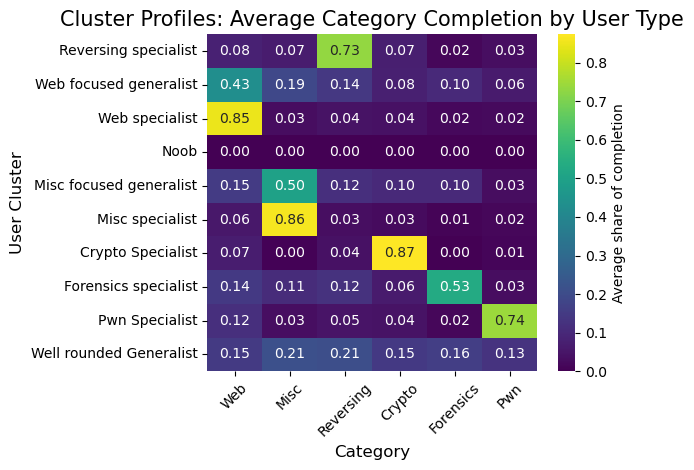

In [45]:
# Average archetype profiles
category_order = ["Web", "Misc", "Reversing", "Crypto", "Forensics", "Pwn"]

avg_heatmap_data = cluster_mean.copy()
avg_heatmap_data.index = avg_heatmap_data.index.map(lambda x: cluster_info[x]['name'])
avg_heatmap_data = avg_heatmap_data.reindex(columns=category_order)
sns.heatmap(
    avg_heatmap_data,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar_kws={'label': 'Average share of completion'} 
)

plt.title('Cluster Profiles: Average Category Completion by User Type', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('User Cluster', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Profiliranje težinom riješenih zadataka

## Struktura tima - carry vs. support

## Struktura tima - profili